# Ujicoba 4: Unsloth CPT on Qwen3.5-9B-Base
## Dual A100 Benchmarking Pipeline

## Environment: DGX A100 80GB (Benchmarking Pipeline)


In [1]:
import subprocess
# Periksa ketersediaan GPU dan Memory
!nvidia-smi
import sys
print(sys.executable)


Sun Apr 19 07:48:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:07:00.0 Off |                    0 |
| N/A   27C    P0             53W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os
import torch
import sys
import shutil
from unittest.mock import MagicMock
import types


env_bin = "/home/riset/miniconda3/envs/unsloth_qwen3/bin"


def create_symlink(target, link_name):
    full_link = os.path.join(env_bin, link_name)
    full_target = os.path.join(env_bin, target)
    if not os.path.exists(full_link):
        try:
            os.symlink(full_target, full_link)
            print(f"✅ Symlink created: {link_name} -> {target}")
        except Exception as e:
            print(f"⚠️ Gagal bikin symlink {link_name}: {e}")

# Lakuin buat gcc dan g++
create_symlink("x86_64-conda-linux-gnu-gcc", "gcc")
create_symlink("x86_64-conda-linux-gnu-g++", "g++")

# 3. SET PATH & COMPILER ALIAS
os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")
os.environ["CC"] = os.path.join(env_bin, "gcc")
os.environ["CXX"] = os.path.join(env_bin, "g++")

# Fix tambahan buat Triton
os.environ["TRITON_USE_CONTEXT_MANAGER"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # Pakai GPU 0 dulu biar stabil
os.environ["WANDB_NOTEBOOK_NAME"] = "uc4_qwen9b_cpt.ipynb"

import gc
import math
import time
import warnings
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import DataCollatorForLanguageModeling, Trainer, TrainingArguments
import wandb

warnings.filterwarnings("ignore")

# W&B Auth (Interactive fallback if not set)
if not os.environ.get("WANDB_API_KEY"):
    wandb.login()
else:
    wandb.login(key=os.environ.get("WANDB_API_KEY"))

if not os.environ.get("HF_TOKEN"):
    from huggingface_hub import login
    from getpass import getpass
    
    print("Masukan HF Token (Cek di huggingface.co/settings/tokens):")
    # Input ini rahasia, karakter tidak akan muncul saat diketik/dipaste
    hf_token = getpass() 
    
    os.environ["HF_TOKEN"] = hf_token
    login(token=hf_token)
    print("✅ HF Login Success!")

    
# Cek apakah sekarang 'which gcc' udah ada isinya
gcc_check = os.popen('which gcc').read().strip()
if gcc_check:
    print(f"🚀 MANTAP! GCC ready at: {gcc_check}")
else:
    print("❌ Waduh, GCC masih belum nemu jalannya.")

def clear_vram():
    gc.collect()
    torch.cuda.empty_cache()


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/riset/.netrc.
wandb: Currently logged in as: daffa-rinali (daffa-rinali-institut-teknologi-sepuluh-nopember) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Masukan HF Token (Cek di huggingface.co/settings/tokens):


 ········


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ HF Login Success!
🚀 MANTAP! GCC ready at: /home/riset/miniconda3/envs/unsloth_qwen3/bin/gcc


In [3]:
# ============================================
# CONFIGURATION
# ============================================
MODEL_NAME = "unsloth/Qwen3.5-9B-Base" 
DATASET_PATH = "./88k_news_cleaned.jsonl"
WANDB_PROJECT = "tim1-dfk-cpt-comparison"
WANDB_RUN = "uc4-qwen35-9b-cpt" 

MAX_ROWS = 44000
MAX_SEQ_LENGTH = 2048

# Training Params
EPOCHS = 3
PER_DEVICE_BATCH = 8
GRAD_ACCUM_STEPS = 8

# LoRA Params
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

# Native setup for A100 (Ampere)
compute_dtype = torch.bfloat16

clear_vram()


## 1. Model Loading (Unsloth)


In [4]:
from unsloth import FastLanguageModel

print("Loading model via Unsloth...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = compute_dtype, 
    load_in_4bit = True,  
)
tokenizer.padding_side = "right"

vram_after_load = torch.cuda.memory_reserved() / 1e9
print(f"[VRAM] After Model Load: {vram_after_load:.2f} GB")

model = FastLanguageModel.get_peft_model(
    model,
    r = LORA_R,
    target_modules = TARGET_MODULES,
    lora_alpha = LORA_ALPHA,
    lora_dropout = LORA_DROPOUT,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

model.print_trainable_parameters()
vram_after_lora = torch.cuda.memory_reserved() / 1e9
print(f"[VRAM] After LoRA Setup: {vram_after_lora:.2f} GB")
clear_vram()


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading model via Unsloth...
==((====))==  Unsloth 2026.4.6: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.495 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

[VRAM] After Model Load: 7.98 GB


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


trainable params: 29,097,984 || all params: 9,438,911,728 || trainable%: 0.3083
[VRAM] After LoRA Setup: 8.10 GB


## 2. Dataset Handling & EDA


Loading dataset from ./88k_news_cleaned.jsonl...
Total Rows Selected: 44000


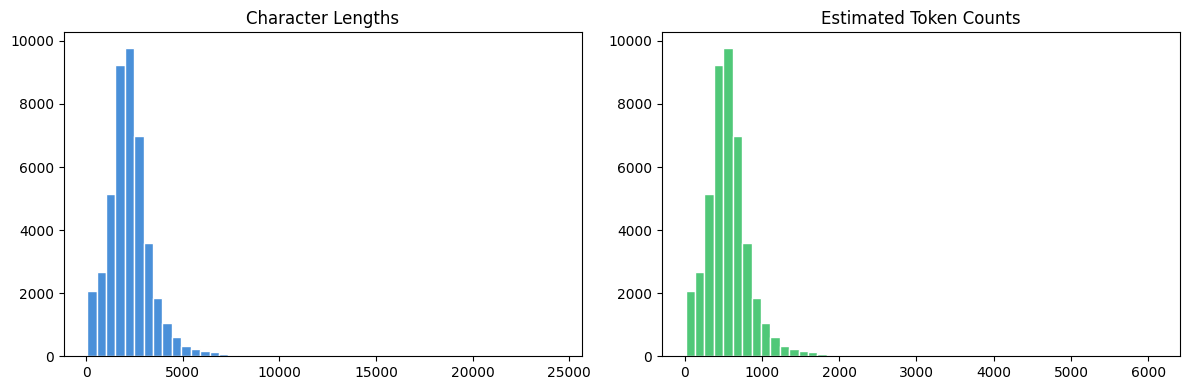

Tokenizing dataset...
Packing dataset (group_texts)...
Packed Train Blocks Ready: 9689


In [5]:
print(f"Loading dataset from {DATASET_PATH}...")
if os.path.exists(DATASET_PATH):
    raw_dataset = load_dataset("json", data_files=DATASET_PATH, split="train")
else:
    # Dummy fallback if file doesn't exist yet
    print("[WARNING] File not found! Using dummy data for setup validity.")
    raw_dataset = load_dataset("json", data_files={"train": [{"text": "Dataset dummy eksperimen DFK. " * 50}] * 20000}, split="train")

# Shuffle with seed 42 then select top 10000
if MAX_ROWS is not None:
    raw_dataset = raw_dataset.shuffle(seed=42).select(range(min(MAX_ROWS, len(raw_dataset))))
else:
    raw_dataset = raw_dataset.shuffle(seed=42)
print(f"Total Rows Selected: {len(raw_dataset)}")

# EDA (Matplotlib)
texts = raw_dataset["text"]
char_lens = [len(t) for t in texts]
token_lens_est = [c / 4 for c in char_lens] # estimated tokens

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(char_lens, bins=50, color="#4A90D9", edgecolor="white")
axes[0].set_title("Character Lengths")
axes[1].hist(token_lens_est, bins=50, color="#50C878", edgecolor="white")
axes[1].set_title("Estimated Token Counts")
plt.tight_layout()
plt.show()

split_dataset = raw_dataset.train_test_split(test_size=0.1, seed=42)

print("Tokenizing dataset...")
def tokenize_fn(examples):
    # ✅ Tambahkan .tokenizer di pemanggilan eos_token dan saat me-return
    texts = [str(text) + tokenizer.tokenizer.eos_token for text in examples["text"]]
    return tokenizer.tokenizer(texts)

tokenized_datasets = split_dataset.map(
    tokenize_fn,
    batched=True,
    remove_columns=split_dataset["train"].column_names,
    desc="Tokenizing..."
)

print("Packing dataset (group_texts)...")
def group_texts(examples):
    # Gabungkan semua token
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated_examples["input_ids"])
    # Buang sisa ekor yang tidak pas
    total_length = (total_length // MAX_SEQ_LENGTH) * MAX_SEQ_LENGTH
    # Pecah jadi gerbong
    result = {
        k: [t[i : i + MAX_SEQ_LENGTH] for i in range(0, total_length, MAX_SEQ_LENGTH)]
        for k, t in concatenated_examples.items()
    }
    return result

packed_datasets = tokenized_datasets.map(
    group_texts,
    batched=True,
    desc=f"Packing to {MAX_SEQ_LENGTH}"
)

train_dataset = packed_datasets["train"]
eval_dataset = packed_datasets["test"]
print(f"Packed Train Blocks Ready: {len(train_dataset)}")


## 3. Baseline Evaluation (Wiki-ID Check)


In [6]:
# Reference general domain strings
print("Mulai")

wiki_texts = [
    "Indonesia adalah negara kepulauan terbesar di dunia yang terletak di Asia Tenggara. Negara ini memiliki keanekaragaman budaya, bahasa, dan agama yang sangat kaya.",
    "Gunung Bromo adalah salah satu gunung berapi aktif yang terletak di Jawa Timur, Indonesia. Gunung ini memiliki ketinggian 2.329 meter di atas permukaan laut.",
    "Bahasa Indonesia adalah bahasa resmi Republik Indonesia dan bahasa persatuan bangsa Indonesia yang diresmikan setelah Proklamasi Kemerdekaan Indonesia pada tahun 1945.",
    "Borobudur adalah candi Buddha terbesar di dunia yang terletak di Magelang, Jawa Tengah. Candi ini dibangun pada abad ke-8 oleh wangsa Sailendra.",
    "Komodo adalah spesies kadal terbesar di dunia yang hanya ditemukan di Kepulauan Komodo, Nusa Tenggara Timur, Indonesia.",
    "Ekonomi Indonesia adalah ekonomi terbesar di Asia Tenggara dan termasuk dalam kelompok G20.",
    "Wayang kulit adalah seni pertunjukan tradisional Indonesia yang menggunakan boneka dari kulit kerbau atau sapi.",
    "Pancasila adalah dasar negara dan ideologi bangsa Indonesia yang terdiri dari lima sila."
]

wiki_encodings = tokenizer.tokenizer(
    [t + tokenizer.tokenizer.eos_token for t in wiki_texts], 
    truncation=True, padding=False, max_length=MAX_SEQ_LENGTH, return_tensors=None,
)
from datasets import Dataset as HFDataset
wiki_dataset = HFDataset.from_dict({
    "input_ids": wiki_encodings["input_ids"],
    "attention_mask": wiki_encodings["attention_mask"]
})

eval_args = TrainingArguments(
    output_dir="./temp_eval",
    per_device_eval_batch_size=1,
    bf16=True,
    fp16=False,
    prediction_loss_only=True,
    report_to="none",
    disable_tqdm=True
)

baseline_trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=wiki_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer.tokenizer, mlm=False) # ✅ Tambahkan .tokenizer di sini
)

print("Evaluating Baseline Wiki-ID (Before Training)...")
baseline_eval = baseline_trainer.evaluate()
baseline_general_ppl = math.exp(baseline_eval["eval_loss"])
print(f"Baseline General PPL: {baseline_general_ppl:.4f}")

del baseline_trainer
clear_vram()


Mulai
Evaluating Baseline Wiki-ID (Before Training)...
{'eval_loss': '1.401', 'eval_model_preparation_time': '0.0284', 'eval_runtime': '11.44', 'eval_samples_per_second': '0.699', 'eval_steps_per_second': '0.699', 'epoch': 0}
Baseline General PPL: 4.0585


## 4. Benchmarking Training


In [ ]:
# NO PERSISTENCE: save_strategy set to "no" purely for efficiency benchmark
training_args = TrainingArguments(
    output_dir=f"./outputs/{WANDB_RUN}",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=PER_DEVICE_BATCH,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_steps=100,
    weight_decay=0.01,
    max_grad_norm=1.0,
    bf16=True,
    fp16=False,
    # logging_steps=5,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    optim="adamw_8bit",
    gradient_checkpointing=True,
    report_to="wandb",
    run_name=WANDB_RUN,
    prediction_loss_only=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer.tokenizer, mlm=False), # ✅ Tambahkan .tokenizer di sini
)

print("Starting Benchmarking Training...")
torch.cuda.reset_peak_memory_stats()
start_time = time.time()

train_result = trainer.train(resume_from_checkpoint = False)

end_time = time.time()
runtime = end_time - start_time
peak_vram = torch.cuda.max_memory_reserved() / 1e9
# tokens_per_sec = train_result.metrics.get('train_samples_per_second', 0) * MAX_SEQ_LENGTH
tokens_per_sec = train_result.metrics.get('train_tokens_per_second', 0) 

print(f"\n[BENCHMARK] Total Training Time: {runtime:.2f} seconds")
print(f"[BENCHMARK] Peak Reserved VRAM: {peak_vram:.2f} GB")
print(f"[BENCHMARK] Throughput: {tokens_per_sec:.2f} tokens/sec")

clear_vram()


Starting Benchmarking Training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,689 | Num Epochs = 3 | Total steps = 456
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 8 x 1) = 64
 "-____-"     Trainable parameters = 29,097,984 of 9,438,911,728 (0.31% trained)


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss


In [ ]:
print("\nSaving LoRA Adapter and Tokenizer...")
trainer.model.save_pretrained("./lora_dfk_uc4_qwen9b")
tokenizer.save_pretrained("./lora_dfk_uc4_qwen9b")
print("Save complete!")


## 5. Post-Eval & Qualitative Checks


In [ ]:
from datasets import Dataset as HFDataset

print("\nRe-evaluating Wiki-ID Domain...")
post_trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=wiki_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer.tokenizer, mlm=False) # ✅ TAMBAHKAN .tokenizer
)
post_eval = post_trainer.evaluate()
final_general_ppl = math.exp(post_eval["eval_loss"])

wiki_degradation = ((final_general_ppl - baseline_general_ppl) / baseline_general_ppl) * 100

print(f"Final General PPL: {final_general_ppl:.4f}")
print(f"Degradation %: {wiki_degradation:.2f}%")

del post_trainer
clear_vram()

# Qualitative Generation
import torch
model.config.use_cache = True
prompts = [
    "Disinformasi di Indonesia terutama menyebar lewat",
    "Narasi ujaran kebencian di masa pemilu rentan memecah",
    "Berita palsu seringkali mengandung judul yang clickbait seperti"
]

print("\n[GENERATION SAMPLES]")
for p in prompts:
    # Tambahkan .tokenizer di inputs, pad_token_id, dan decode
    inputs = tokenizer.tokenizer(p, return_tensors="pt").to("cuda") 
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=50, temperature=0.7, top_p=0.9, do_sample=True, pad_token_id=tokenizer.tokenizer.eos_token_id)
    print(f"Prompt: {p}\nOutput: {tokenizer.tokenizer.decode(out[0], skip_special_tokens=True)}\n")

model.config.use_cache = False
clear_vram()


## 6. Finish & WandB Logistics


In [ ]:
wandb.log({
    "Benchmark/Peak_VRAM_GB": peak_vram,
    "Benchmark/Runtime_Secs": runtime,
    "Benchmark/Tokens_Per_Sec": tokens_per_sec,
    "Eval/Baseline_Wiki_PPL": baseline_general_ppl,
    "Eval/Final_Wiki_PPL": final_general_ppl,
    "Eval/Wiki_Degradation_Pct": wiki_degradation,
})
wandb.finish()
print("Experiment Logs synchronized to W&B successfully!")
